<hr/>
<h1>4. Feature Engineering</h1>

<p>In this section of Feature Engineering, I will be doing many operations such as creating dummy variables, removing outliers and creating new features. Feature Engineering plays an important role in ensuring my model can be trained with the dataset and also ensures that the accuracy of my model is not compromised in any case especially if it is due to the presence of outliers. However, many operation for Feature Engineering will be up to my discretion due to there not being a clear answer in many of the decisions which I need to make.</p>

<hr/>
<h2>4.1 Identifying Outliers</h2>

<p>In this sub-section, I will be Identifying Outliers using visualisations. Subsequently, I will need to address the Outliers accordingly on a case by case basis as some Outliers may not neccessarily have a negative effect. Outliers can cause a model to have lower accuracy level due to there being unrealistic datas which can skew the results, affecting the model's ability to cluster properly. The easiest and most used method to visualise outlier is using a Boxplot. A Boxplot will contain a few important parts such as the minimum, maximum, lower quartile, second quartile (median), and upper quartile. With all these parts present, I am able to perform and visualise important calculations such as the Inter-Quartile Range which will assist us in establishing the lower and upper fence should there be any Outliers. An Outlier will be flagged if it is below the Minimum or above the Maximum. Through the Boxplot, I am also able to visualise how many Outliers is present within a Numerical Category. As 'Gender' is represented by Dummy Variable, it will be excluded from this operation. The action plan for this section has been listed below.</p>
<br/>
<span style="color:red"><p><strong><u>Outliers Identified</u></strong></p></span>
<ul>
    <li>Proceed to determine the best course of action to undertake so as to address the Outlier.</li>
    <li>Execute the planned out action in the next section.</li>
</ul>
<span style="color:green"><p><strong><u>No Outliers Identified</u></strong></p></span>
<ul>
    <li>Proceed to the next sub-section.</li>
</ul>
<br/>
<p>With the action plan laid out, we will proceed to identify the Outliers in all Numerical Data.</p>

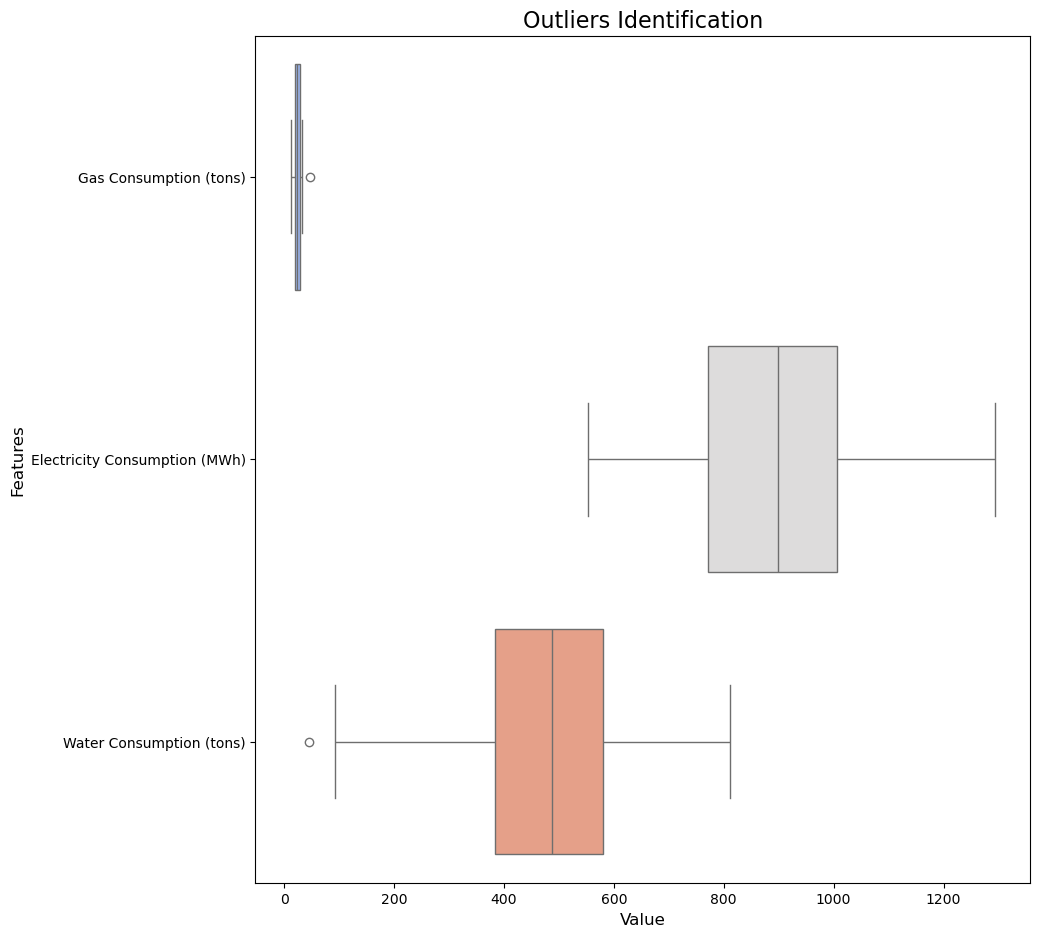

In [65]:
# ---------- Filter Numeric Columns Only ---------- #
numeric_columns = df.select_dtypes(include=['float64', 'int32', 'int64']).columns

# ---------- Plot Boxplots for All Numeric Columns ---------- #
plt.figure(figsize=(10, 11))
sns.boxplot(data=df[numeric_columns], orient='h', palette='coolwarm')
plt.title('Outliers Identification', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

<p>With reference to the output of the Boxplot above, I am able to determine that there is indeed an outlier for income where there is a data point at around 140k\$. Therefore, the result of the identification is concluded as <span style="color:red"><strong><u>Outliers Identified</u></strong></span>. The best course of action has been listed below.</p>
<br/>
<p><strong><u>Gas Consumption (tons)</u></strong></p>
<ul>
    <li>Course of Action: IQR Method</li>
    <li>Reason: Due to Gas Consumption (tons) being skewed to the left.</li>
</ul>
<p><strong><u>Water Consumption (tons)</u></strong></p>
<ul>
    <li>Course of Action: IQR Method</li>
    <li>Reason: Due to Gas Consumption (tons) being skewed to the left.</li>
</ul>
<br/>
<p>With the best Course of Action listed out, I will proceed to remove the Outlier from the Dataset.</p>

<hr/>
<h2>4.2 Addressing Outliers Using IQR Method</h2>

<p>The IQR Method requires the establishment of a Upper Fence and Lower Fence such that any data which are above the Upper Fence will be deemed invalid and illegitimate and will be removed whereas any data which are below the Lower Fence will be deemed likewise and removed. In the cells below, I will be removing Outliers using the IQR Method.</p>

$$\text{IQR} = \text{Q3} - \text{Q1}$$
$$\text{Lower Fence} = \text{Q1} - 1.5 \times \text{IQR}$$
$$\text{Upper Fence} = \text{Q3} + 1.5 \times \text{IQR}$$
<br/>
<p>With the formulas listed, I will proceed with identifying and removing the Outliers.</p>

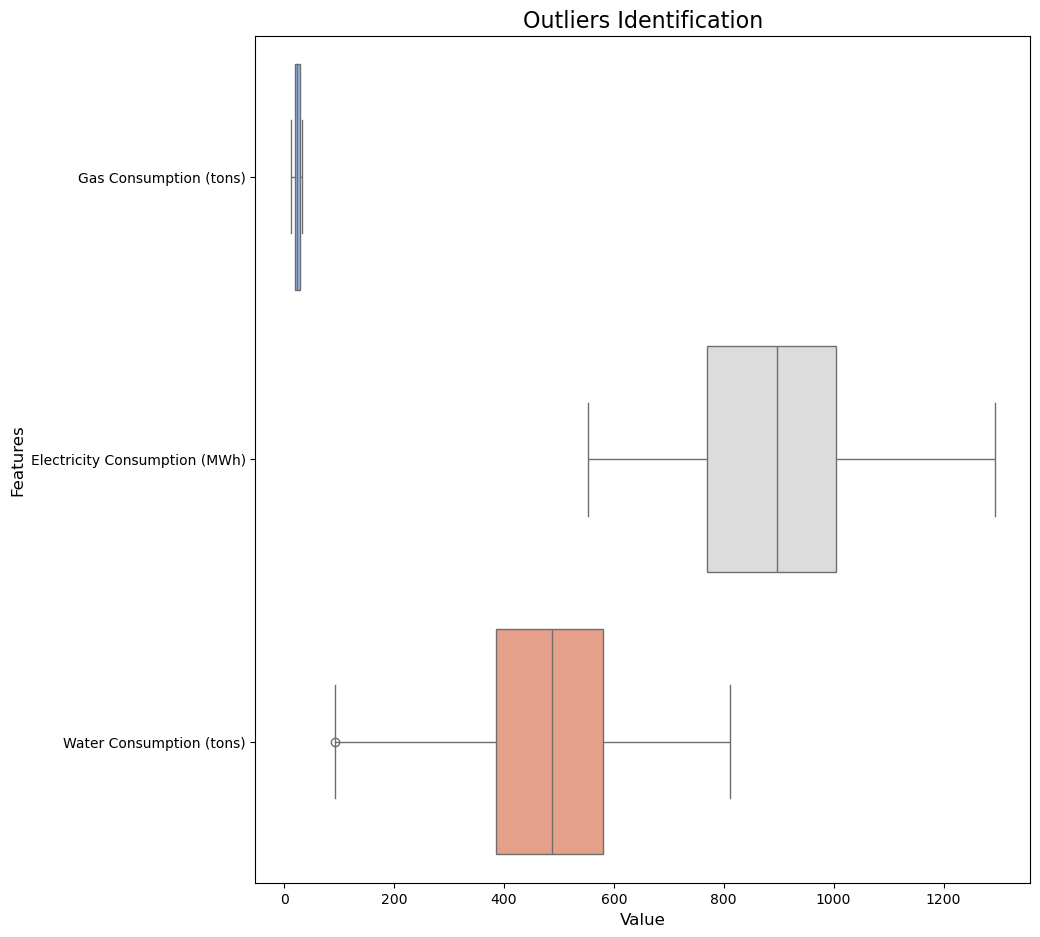

In [69]:
# ---------- Columns With Outliers ---------- #
columns = [
    'Gas Consumption (tons)',
    'Water Consumption (tons)'
]

# ---------- Function For Upper And Lower Bounds Calculations ---------- #
def calculate_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# ---------- Flagging Of Outliers ---------- #
for col in columns:
    # Calculate bounds for the current column
    lower_bound, upper_bound = calculate_bounds(df[col])
    
    # Create a mask for outliers, ignoring NaN values
    df[f'Outlier_{col}'] = ((df[col] < lower_bound) | (df[col] > upper_bound)) & ~df[col].isna()

# ----------- Removal Of Outliers ---------- #
for col in columns:
    # Retain NaN values and remove only rows flagged as outliers
    df = df[(df[f'Outlier_{col}'] == False) | (df[col].isna())]

# ---------- Removal Of Data Column Used For Calculation ---------- #
outlier_cols = [f'Outlier_{col}' for col in columns]
df.drop(outlier_cols, axis=1, inplace=True)

# ---------- Filter Numeric Columns Only ---------- #
numeric_columns = df.select_dtypes(include=['float64', 'int32', 'int64']).columns

# ---------- Plot Boxplots for All Numeric Columns ---------- #
plt.figure(figsize=(10, 11))
sns.boxplot(data=df[numeric_columns], orient='h', palette='coolwarm')
plt.title('Outliers Identification', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

<p>With reference to the output of the Boxplot above, I am able to verify that the Outlier have been successfully removed and the Upper and Lower Fence have been successfully established. As there are no more Outliers remaining, I will proceed with Data Exploration of the new DataFrame.</p>

<hr/>
<h2>4.3 Data Exploration of Updated DataFrame</h2>

<p>In this sub-section, I will be exploring the new DataFrame which have been ammended in the previous sub-section as the Outliers have been addressed. Thoughout this sub-section, I will mainly focus on what has changed compared to before the removal of some Outliers.</p>

<hr/>
<h3>4.3.1 Shape of Updated DataFrame</h3>

<p>I will be running the shape method to view how many data rows are remaining as compared to before removing some of the Outliers. This will give me insights on what is the scale of the new data that I am working with.</p>

In [75]:
# ----------- df's Shape ----------- #
shape_data = {'Attribute': ['Rows', 'Columns'], 'Count': list(df.shape)}

# ----------- Putting Shape Into DataFrame ----------- #
df_shape = pd.DataFrame(shape_data)

# ----------- Displaying DataFrame ----------- #
df_shape.style.background_gradient(cmap="Blues")

,Attribute,Count
0,Rows,396
1,Columns,3


<p>With reference to the output of the DataFrame, I am able to confirm that there was only a total of 1 Outliers which was removed using the IQR Method. This means that I did not lose much data as compared to the original 200 Data Rows.</p>

<hr/>
<h3>4.3.2 Description of Updated DataFrame</h3>

<p>The last operation which I will perform on the new data is using the describe function. This will describe all the numerical data's information such as mean, standard deviation, etc. As all the data columns are now numerical, I should be able to see all the data column present.</p>

In [79]:
# ----------- Describing DataFrame ----------- #
df.describe().style.background_gradient(cmap="Blues")

,Gas Consumption (tons),Electricity Consumption (MWh),Water Consumption (tons)
count,396.000000,396.000000,396.000000
mean,23.729040,888.079293,486.066162
std,4.780397,153.872378,132.228508
min,11.600000,553.200000,91.900000
25%,20.175000,770.200000,385.225000
50%,23.450000,897.700000,487.400000
75%,27.825000,1004.600000,580.225000
max,33.000000,1294.000000,811.000000


<p>From the output of the DataFrame above, I am able to see that generally, all the data have not changed much even after the remvoal of the outliers.</p>